In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches 
import seaborn as sns
import pandas as pd

In [3]:
project = fw_project.reload()

In [3]:
COR = {"failed":0,"passed":0, "unclear":0}
SAG = {"failed":0,"passed":0, "unclear":0}
AXI = {"failed":0,"passed":0, "unclear":0}

quality = pd.DataFrame()
all_rows = []

In [10]:
all_rows = []
for subject in project.subjects():
    
    subject = subject.reload()
    if subject.type != 'phantom':
        for session in subject.sessions():
            session = session.reload()
            planes = ["COR", "AXI","SAG"]
            acquisitions = [acq for acq in session.acquisitions() if "T2" in acq.label and any(elem in acq.label.upper() for elem in planes)]
            for acq in acquisitions:
                niftis = [file for file in acq.files if file.name.endswith('nii.gz') and "read" not in file.tags]
                print([file.tags+[file.name] for file in niftis])
                for file in niftis:
                    
                    row = {"Subject":subject.label, "Session": session.label,"Acq": next((o for o in planes if o in acq.label.upper()), None), "File": file.name, "Tags":file.tags}
                    all_rows.append(row)

[['QC-unclear', '5_T2_AXI_Fast.nii.gz']]
[['QC-unclear', '7_T2_SAG_Fast.nii.gz']]
[['QC-passed', '6_T2_COR_Fast.nii.gz']]
[['QC-unclear', '5_T2_AXI_Fast_NOT_FOR_DIAGNOSTIC_USE.nii.gz']]
[['QC-unclear', '7_T2_COR_Fast_NOT_FOR_DIAGNOSTIC_USE.nii.gz']]
[['QC-unclear', '6_T2_SAG_Fast_NOT_FOR_DIAGNOSTIC_USE.nii.gz']]
[['QC-unclear', '5_T2_AXI_Fast.nii.gz']]
[['QC-unclear', '7_T2_SAG_Fast.nii.gz']]
[['QC-unclear', '6_T2_COR_Fast.nii.gz']]
[['QC-unclear', '6_T2_COR_Fast.nii.gz']]
[['QC-unclear', '5_T2_AXI_Fast.nii.gz']]
[['QC-unclear', '7_T2_SAG_Fast.nii.gz']]
[['QC-passed', '5_T2_AXI_Fast.nii.gz']]
[['QC-failed', '7_T2_SAG_Fast.nii.gz']]
[['QC-unclear', '6_T2_COR_Fast.nii.gz']]
[['QC-unclear', '5_T2_AXI_Fast.nii.gz']]
[['QC-failed', '6_T2_COR_Fast.nii.gz']]
[['QC-passed', '7_T2_SAG_Fast.nii.gz']]
[['QC-unclear', '5_T2_AXI_Fast_NOT_FOR_DIAGNOSTIC_USE.nii.gz']]
[['QC-unclear', '7_T2_COR_Fast_NOT_FOR_DIAGNOSTIC_USE.nii.gz']]
[['QC-failed', '6_T2_SAG_Fast_NOT_FOR_DIAGNOSTIC_USE.nii.gz']]
[['QC-u

In [11]:
if all_rows:
    #print(df)
    df_pd = pd.DataFrame.from_dict(all_rows)
    df_pd.to_csv('filetags.csv',index=False)

In [4]:
for subject in project.subjects():
    
    subject = subject.reload()
    for session in subject.sessions():
        session = session.reload()
        df = {"Subject":subject.label, "Session": session.label,"COR":"missing", "AXI":"missing","SAG":"missing"}
        cor, sag, axi, qc_all = True, True, True, True
        
        for acq in session.acquisitions():
            acq = acq.reload()
            
            
            if "QC-failed" in acq.tags:
                if "COR" in acq.label.upper():
                    cor = False
                    qc_all = False
                    df["COR"] = "failed"
                    
                    COR["failed"] = COR["failed"] + 1
                    
                elif "AXI" in acq.label.upper():
                    axi = False
                    qc_all = False
                    AXI["failed"] = AXI["failed"] + 1
                    df["AXI"] = "failed"
                    
                elif "SAG" in acq.label.upper():
                    sag = False
                    qc_all = False
                    SAG["failed"] = SAG["failed"] + 1
                    df["SAG"] = "failed"
                    
            elif "QC-unclear" in acq.tags:
                if "COR" in acq.label.upper():
                    COR["unclear"] = COR["unclear"] + 1
                    df["COR"] = "unclear"
                    
                elif "AXI" in acq.label.upper():
                    AXI["unclear"] = AXI["unclear"] + 1
                    df["AXI"] = "unclear"
                elif "SAG" in acq.label.upper():
                    SAG["unclear"] = SAG["unclear"] + 1
                    df["SAG"] = "unclear"
                    
            elif "QC-passed" in acq.tags:
                if "COR" in acq.label.upper():
                    COR["passed"] = COR["passed"] + 1
                    df["COR"] = "passed"
                elif "AXI" in acq.label.upper():
                    AXI["passed"] = AXI["passed"] + 1
                    df["AXI"] = "passed"
                elif "SAG" in acq.label.upper():   
                    SAG["passed"] = SAG["passed"] + 1
                    df["SAG"] = "passed"
                    
        all_rows.append(df)
        
        

In [7]:
if all_rows:
    #print(df)
    df_pd = pd.DataFrame.from_dict(all_rows)
    df_pd["QC"] = df_pd[["SAG", "COR", "AXI"]].apply(
            lambda row: "failed" if ("failed" in row.values or row.isnull().any() or "missing" in row.values) else "passed",
            axis=1
        )
    
    df_pd.to_csv(f'quality_scans_pilot.csv', index=False)

In [8]:
df_pd.QC.value_counts()

QC
failed    26
passed    23
Name: count, dtype: int64

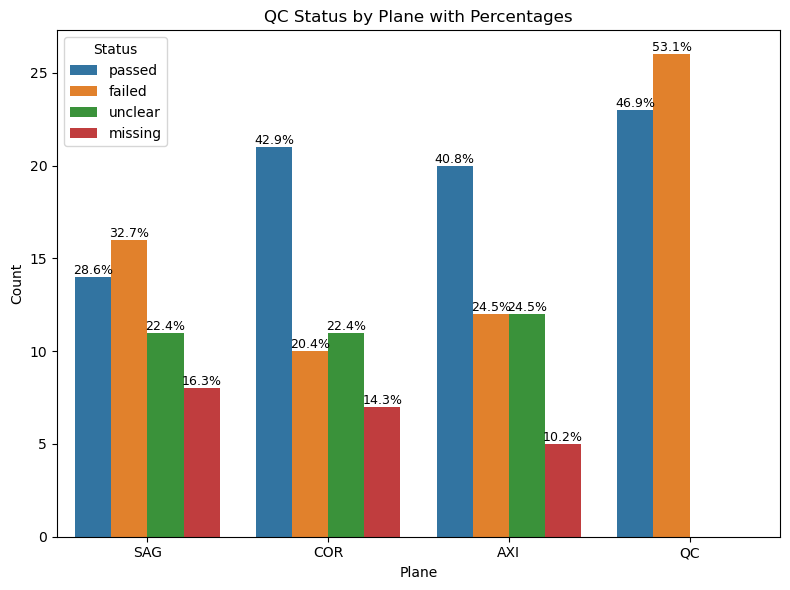

In [54]:

# Suppose df is your DataFrame with columns: 'SAG', 'COR', 'AXI', 'QC'

# Reshape the DataFrame
df_melted = df_pd.melt(value_vars=['SAG', 'COR', 'AXI', 'QC'],
                    var_name='Plane',
                    value_name='Status')

total_counts = df_melted.groupby('Plane').size()

# Create the countplot
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_melted, x='Plane', hue='Status',
                   order=['SAG', 'COR', 'AXI', 'QC'],
                   hue_order=['passed', 'failed', 'unclear','missing'])  # adjust as needed

# Add percentage labels
total_counts = df_melted.groupby('Plane').size()

# Go through each bar to add percentages
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height == 0:
            continue  # skip bars with zero height
        plane = bar.get_x() + bar.get_width() / 2
        label_x = bar.get_x() + bar.get_width() / 2
        label_y = height
        # Get Plane name from bar
        plane_index = int(round(label_x))  # assuming default bar width spacing
        plane_name = ax.get_xticks()[plane_index]
        plane_label = ax.get_xticklabels()[plane_index].get_text()
        plane_total = total_counts[plane_label]
        percentage = height / plane_total * 100
        ax.text(label_x, label_y, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9)

# Styling
plt.title('QC Status by Plane with Percentages')
plt.ylabel('Count')
plt.xlabel('Plane')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [10]:
failed_analyses = pd.DataFrame(columns=["Subject", "Session","Analysis"])
asys_gambas , asys_mrr = None, None
asys_rows = []
gear_v = {"recon-all-clinical":"0.4.1","mrr":"0.1.5","gambas":"0.4.4"}
for subject in project.subjects():
    subject = subject.reload()
    for session in subject.sessions():
        session = session.reload()
        df = {"Subject":subject.label, "Session": session.label}
        for asys in session.analyses:
            gear_name = asys.gear_info.get('name', None) if asys.gear_info else None
            gear_version = asys.gear_info.get('version') if asys.gear_info else None
            created_date = asys.created

            if gear_name == "recon-all-clinical" and gear_version == gear_v[gear_name]:
                #last_run_date_recon = max(last_run_date_recon, created_date) if last_run_date_recon else created_date
                asys_recon = asys

            elif gear_name == "mrr" and gear_version == gear_v[gear_name]:
                #last_run_date_mrr = max(last_run_date_mrr, created_date) if last_run_date_mrr else created_date
                asys_mrr = asys
            elif gear_name == "gambas" and gear_version == gear_v[gear_name]:
                #last_run_date_gambas = max(last_run_date_gambas, created_date) if last_run_date_gambas else created_date
                asys_gambas = asys

        # Record job states
        # Collect state info
        #if asys_recon:
        #    state = asys_recon.job.get("state") 
        #    all_runs.append("recon-all-clinical (v"+ asys_recon.gear_info.get('version')+")")
        #    run_states.append(state)

            #if run failed, add to a list and save to CSV
        #    if state == "failed":
        #        failed_analyses.loc[len(failed_analyses),:] = [subject_label,session_label,"recon-all-clinical"]

        if asys_mrr:
            state = asys_mrr.job.get("state")
            df["MRR Analysis"] =  state
        if asys_gambas:
            state = asys_gambas.job.get("state")
            df["Gambas Analysis"] =  state
            
    
    asys_rows.append(df)
            

In [11]:
if asys_rows:
    #print(df)
    df_asys = pd.DataFrame.from_dict(asys_rows)
    
    df_asys.to_csv(f'asys_df.csv', index=False)

In [12]:
#try to figure out which ones failed, does it coincide with missing planes?
df_all = pd.merge(df_pd, df_asys, on=["Subject","Session"])
df_all.to_csv("analyses_status_mrr.csv", index=False)
display(df_all)

,Subject,Session,COR,AXI,SAG,QC,MRR Analysis
0,134-400287,2024-01-23 09_49_51,unclear,failed,missing,failed,failed
1,134-400138,2024-01-22 09_02_32,passed,passed,passed,passed,complete
2,134-400244,2024-01-18 10_40_45,passed,passed,unclear,passed,complete
3,134-400194-1,2024-01-17 10_33_50,failed,failed,failed,failed,failed
4,134-400231,2024-01-16 09_37_52,missing,missing,missing,failed,failed
5,134-400236,2024-01-16 08_37_06,failed,failed,failed,failed,failed
6,134-400367,2024-01-11 13_04_57,passed,passed,passed,passed,complete
7,134-400256,2023-12-14 09_23_00,unclear,failed,failed,failed,failed
8,134-400245,2023-12-14 10_09_50,failed,passed,failed,failed,failed
9,134-400260,2024-02-15 09_06_16,failed,unclear,failed,failed,failed


In [13]:
df_asys.head()

,Subject,Session,MRR Analysis
0,134-400287,2024-01-23 09_49_51,failed
1,134-400138,2024-01-22 09_02_32,complete
2,134-400244,2024-01-18 10_40_45,complete
3,134-400194-1,2024-01-17 10_33_50,failed
4,134-400231,2024-01-16 09_37_52,failed


In [14]:
df_pd.head()

,Subject,Session,COR,AXI,SAG,QC
0,134-400287,2024-01-23 09_49_51,unclear,failed,missing,failed
1,134-400138,2024-01-22 09_02_32,passed,passed,passed,passed
2,134-400244,2024-01-18 10_40_45,passed,passed,unclear,passed
3,134-400194-1,2024-01-17 10_33_50,failed,failed,failed,failed
4,134-400231,2024-01-16 09_37_52,missing,missing,missing,failed


In [19]:
combos = df_all[['QC', 'MRR Analysis']].value_counts()

print(combos)

QC      MRR Analysis
failed  failed          20
passed  complete        16
failed  complete         5
passed  failed           1
Name: count, dtype: int64


In [7]:
df_all = pd.read_csv('analyses_status_mrr.csv')
outcome_data = pd.read_excel('OutcomeData_13NOV2024.xlsx')

In [11]:
outcome_data.rename(columns={"record_id":"Subject"} , inplace=True)
outcome_data.head(4)

,Subject,id,redcap_repeat_instrument,redcap_repeat_instance,motheo_pid,date_contacted,who_contacted,who_other,mother_contacts,invite_response,...,caregiver_feel_after,caregiver_feel_change,caregiver_betterworse,exp_better,rec_scan,rec_scan_no,rec_comments,comments_other,visit_hrs,mri_enrollment_study_visit_complete
0,134-400010,134-400010,recruitment_tracking_form_1,1,134-400010,2023-12-13 00:00:00,4.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,134-400010,134-400010,recruitment_tracking_form_1,2,134-400010,2024-01-23 00:00:00,1.0,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,134-400010,134-400010,mri_enrollment_study_visit,1,NaN,#NULL!,NaN,NaN,NaN,NaN,...,fine,1.0,NaN,having the mother close to the child during th...,1.0,NaN,none,none,130.0,2.0
3,134-400018,134-400018,recruitment_tracking_form_1,1,134-400018,2023-11-28 00:00:00,4.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df_all.head(5)

,Subject,Session,COR,AXI,SAG,QC,MRR Analysis
0,134-400287,2024-01-23 09_49_51,unclear,failed,missing,failed,failed
1,134-400138,2024-01-22 09_02_32,passed,passed,passed,passed,complete
2,134-400244,2024-01-18 10_40_45,passed,passed,unclear,passed,complete
3,134-400194-1,2024-01-17 10_33_50,failed,failed,failed,failed,failed
4,134-400231,2024-01-16 09_37_52,missing,missing,missing,failed,failed


In [12]:
df_outcome_scans = pd.merge(df_all, outcome_data, on=["Subject"])

In [27]:
df_sub = df_outcome_scans[["Subject","COR","AXI","SAG","QC", "child_comfort", "child_move","child_comfort_help","child_sleep","scan_pause","interrupt","scan_seq_comm","scan_seq_comp","scan_seq_not_comp"]]

It seems like **positioning** was an issue a few times, which the technicians got alerted about.
**Movement** due to startling 

In [28]:
df_sub[df_sub["QC"]=="failed"][["Subject","COR","AXI","SAG","QC","interrupt","scan_seq_comm","scan_seq_comp","scan_seq_not_comp"]]

,Subject,COR,AXI,SAG,QC,interrupt,scan_seq_comm,scan_seq_comp,scan_seq_not_comp
0,134-400287,unclear,failed,missing,failed,NaN,NaN,NaN,NaN
1,134-400287,unclear,failed,missing,failed,NaN,"the child was comfortable and cooperative ,but...",1.0,NaN
6,134-400231,missing,missing,missing,failed,NaN,NaN,NaN,NaN
7,134-400231,missing,missing,missing,failed,CHILD WAS CALM GETTING INTO THE SCANNER HEAD C...,NOT COMPLETED,0.0,"T2 (AXI, Fast) T2 (COR, Fast) T2 (SAG, Fast)..."
8,134-400231,missing,missing,missing,failed,NaN,NaN,NaN,NaN
9,134-400236,failed,failed,failed,failed,NaN,NaN,NaN,NaN
10,134-400236,failed,failed,failed,failed,the child got startled by the noise int the s...,the child went into the scanner without any pr...,1.0,NaN
13,134-400256,unclear,failed,failed,failed,NaN,NaN,NaN,NaN
14,134-400256,unclear,failed,failed,failed,an alert showed on the iPad that child should ...,the child was uncomfortable and hesitant to en...,1.0,NaN
15,134-400245,failed,passed,failed,failed,NaN,NaN,NaN,NaN


382: Scan has AXI (on top of localizer) in the second upload
287: Acqusitions complete on second scan